In [ ]:
from datasets import load_dataset

ds = load_dataset("weathon/aas_benchmark_final")

In [ ]:
from datasets import load_dataset
vsf_ds = load_dataset("weathon/nag_dataset")

README.md:   0%|          | 0.00/670 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/503M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/503M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/477M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [ ]:
from PIL import Image

In [ ]:
# vsf = [Image.open(f"{i}.png") for i in idx]

In [ ]:
# import pandas as pd
# df = pd.DataFrame(ds.remove_columns(["image_distorted", "image_original"])["train"])

In [ ]:
vsf_ds

DatasetDict({
    train: Dataset({
        features: ['prompt', 'negative_prompt', 'image', 'method', 'alpha', 'blip_score', 'hpsv3_score_aa', 'hpsv3_scores_original', 'rater'],
        num_rows: 1200
    })
})

In [ ]:
idx = [16, 207, 266, 279, 49, 85]#, 259, 63, 70, 80, 109]

In [ ]:
nano_banana = [ds["train"][i]["image_distorted"] for i in idx]
nano_banana_hpsv3_score_aa = []
for i in idx:
  try:
    nano_banana_hpsv3_score_aa.append(ds["train"][i]["hpsv3_reward"]["hpsv3_reward"]["hpsv3_didp"][0])
  except:
    nano_banana_hpsv3_score_aa.append(ds["train"][i]["hpsv3_reward"]["hpsv3_didp"][0])
nano_banana_hpsv3_score_original = []
for i in idx:
  try:
    nano_banana_hpsv3_score_original.append(ds["train"][i]["hpsv3_reward"]["hpsv3_reward"]["hpsv3_diop"][0])
  except:
    nano_banana_hpsv3_score_original.append(ds["train"][i]["hpsv3_reward"]["hpsv3_diop"][0])
vsf = [vsf_ds["train"][i]["image"] for i in idx]
vsf_hpsv3_score_aa = [vsf_ds["train"][i]["hpsv3_score_aa"] for i in idx]
vsf_hpsv3_score_original = [vsf_ds["train"][i]["hpsv3_scores_original"] for i in idx]

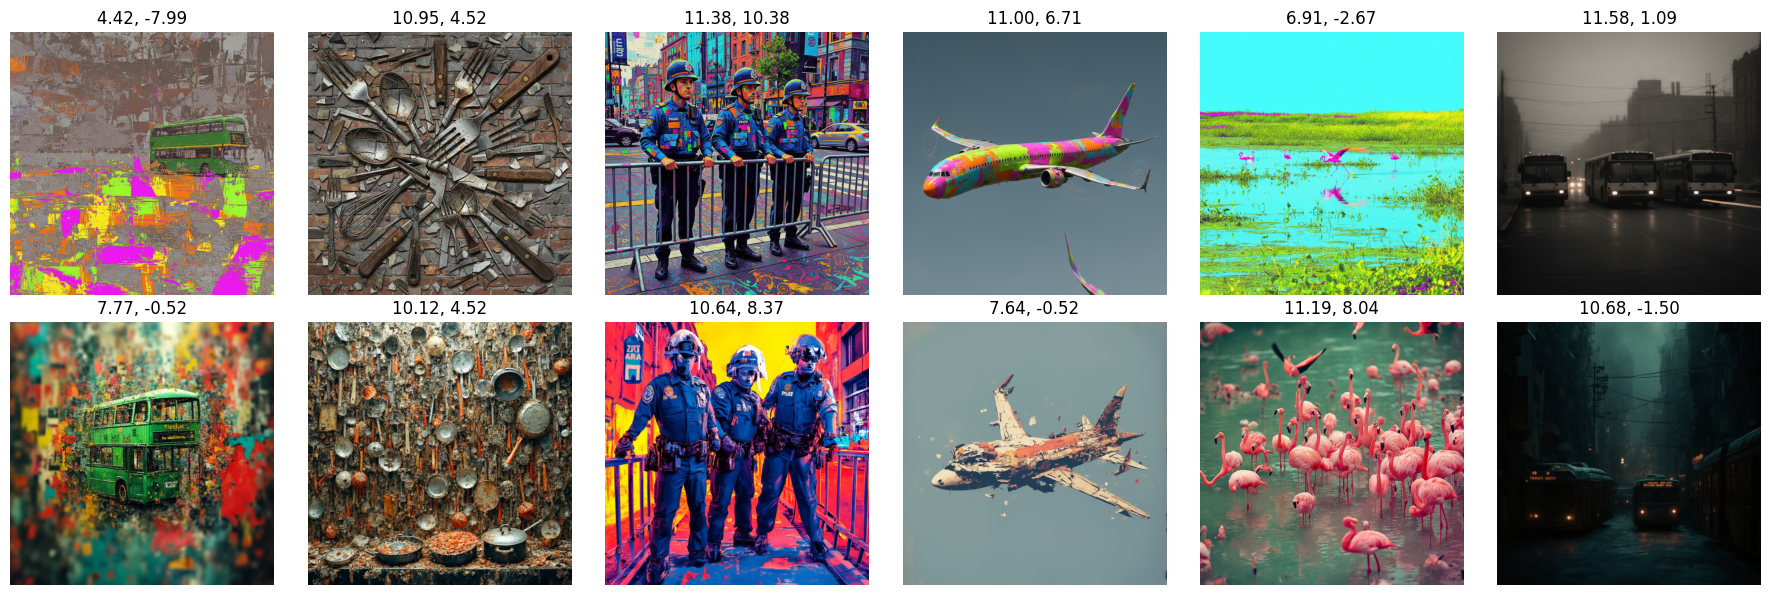

In [ ]:
import pylab
pylab.figure(figsize=(18, 6))
for i in range(len(nano_banana)):
  pylab.subplot(2, len(nano_banana), i + 1)
  if i==0:
    pylab.ylabel("Nano Banana")
  pylab.imshow(nano_banana[i])
  pylab.title(f"{nano_banana_hpsv3_score_aa[i]:.2f}, {nano_banana_hpsv3_score_original[i]:.2f}")
  pylab.axis("off")

for i in range(len(vsf)):
  pylab.subplot(2, len(vsf), i + 1 + len(vsf))
  if i==0:
    pylab.ylabel("VSF")
  pylab.imshow(vsf[i])
  pylab.title(f"{vsf_hpsv3_score_aa[i]:.2f}, {vsf_hpsv3_score_original[i]:.2f}")
  pylab.axis("off")
pylab.tight_layout()
pylab.savefig("vsf.pdf")
pylab.show()

In [ ]:
import pandas as pd
vsf_df = pd.DataFrame(vsf_ds["train"].remove_columns("image"))

In [ ]:
vsf_df["selected_dims"] = list(ds["train"]["selected_dims"][:300]) * 4

In [ ]:
dims = ['background', 'clarity', 'color aesthetic', 'color brightness', 'detail realism', 'detail refinement', 'emotion', 'lighting distinction', 'main object', 'object pairing', 'richness']

In [ ]:
import json

In [ ]:
import numpy as np
vsf_df["match_ratio"] = vsf_df["blip_score"] > 0.5
rater_selected = []
for i in range(len(vsf_df)):
  row = vsf_df.iloc[i]
  selected_dim_index = [dims.index(i) for i in json.loads(row["selected_dims"])]
  cache = []
  for index in selected_dim_index:
    cache.append(row["rater"]["scores"][index])

  rater_selected.append(np.mean(cache))

In [ ]:
vsf_df["rater_selected"] = rater_selected

In [ ]:
vsf_df["rater_selected"] = rater_selected
res = vsf_df.groupby(["method", "alpha"])[["hpsv3_scores_original", "rater_selected", "blip_score"]].mean()

In [ ]:
res

hpsv3_scores_original  rater_selected  blip_score  \
method    alpha                                                      
DanceFlux 10.0                3.813824        0.694669    0.958151   
          15.0               -0.347187        0.598849    0.940188   
Flux Krea 4.0                -3.290831        0.621487    0.942523   
          10.0               -8.365153        0.454866    0.827330   

                 match_ratio  
method    alpha               
DanceFlux 10.0      0.983333  
          15.0      0.960000  
Flux Krea 4.0       0.950000  
          10.0      0.833333

from matplotlib import pyplot as plt
_df_0['hpsv3_scores_original'].plot(kind='hist', bins=20, title='hpsv3_scores_original')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['rater_selected'].plot(kind='hist', bins=20, title='rater_selected')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['blip_score'].plot(kind='hist', bins=20, title='blip_score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['match_ratio'].plot(kind='hist', bins=20, title='match_ratio')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='blip_score', y='match_ratio', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['hpsv3_scores_original'].plot(kind='line', figsize=(8, 4), title='hpsv3_scores_original')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_8['rater_selected'].plot(kind='line', figsize=(8, 4), title='rater_selected')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['blip_score'].plot(kind='line', figsize=(8, 4), title='blip_score')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['match_ratio'].plot(kind='line', figsize=(8, 4), title='match_ratio')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
res.to_latex(float_format="%.03f")

'\\begin{tabular}{llrrr}\n\\toprule\n &  & hpsv3_scores_original & rater_selected & blip_score \\\\\nmethod & alpha &  &  &  \\\\\n\\midrule\n\\multirow[t]{2}{*}{DanceFlux} & 10.000000 & 3.814 & 0.695 & 0.958 \\\\\n & 15.000000 & -0.347 & 0.599 & 0.940 \\\\\n\\cline{1-5}\n\\multirow[t]{2}{*}{Flux Krea} & 4.000000 & -3.291 & 0.621 & 0.943 \\\\\n & 10.000000 & -8.365 & 0.455 & 0.827 \\\\\n\\cline{1-5}\n\\bottomrule\n\\end{tabular}\n'